In [ ]:
import numpy as np
from case_studies import * 

# Utility to project initial point onto feasible set
def project_initial_point(x0, A, b):
    """Project x0 onto the set {x | Ax + b = 0}."""
    return x0 - A.T @ np.linalg.inv(A @ A.T) @ (A @ x0 + b)

def backtracking_line_search(f, df, x, p, alpha=1.0, rho=0.5, c1=1e-4):
    while f(x + alpha * p) > f(x) + c1 * alpha * np.dot(df(x), p):
        alpha *= rho
    return alpha

def solve_linear_system(B, A, grad_f):
    """Solve the KKT system [B A^T; A 0][p; lambda] = [-grad_f; 0]."""
    m, n = A.shape
    zero_block = np.zeros((m, m))
    lhs = np.block([[B, A.T], [A, zero_block]])
    rhs = np.concatenate([-grad_f, np.zeros(m)])
    try:
        solution = np.linalg.solve(lhs, rhs)
        p_k = solution[:n]
        lambda_k = solution[n:]
        return p_k, lambda_k
    except np.linalg.LinAlgError:
        print("Warning: Singular matrix in KKT system")
        return None, None

# Constrained Newton's Method
def constrained_newton(f, df, Hf, A, b, x0, tol=1e-9, max_iter=1000, alpha_init=1.0, rho=0.5, c1=1e-4):
    """Newton's method with linear equality constraints Ax + b = 0."""
    x_k=x0
    xs = [x_k.copy()]
    grad_norms = []

    for k in range(max_iter):
        grad = df(x_k)
        H = Hf(x_k)
        
        # Check Hessian positive definiteness
        eigvals = np.linalg.eigvalsh(H)
        if eigvals.min() > 0:
            B = H
        else:
            eigvals, eigvecs = np.linalg.eigh(H)
            B = sum(np.abs(l) * np.outer(v, v) for l, v in zip(eigvals, eigvecs.T))

        # Solve KKT system
        p_k, lambda_k = solve_linear_system(B, A, grad)

        # # Check constraint satisfaction
        # constraint_error = np.linalg.norm(A @ x_k + b)
        # if constraint_error > 1e-10:
        #     print(f"Iteration {k}: Constraint violation = {constraint_error}")
        
        # Stopping criterion:
        grad_norm = np.linalg.norm(grad-A.T @ np.linalg.inv(A @ A.T) @ A @ grad)
        grad_norms.append(grad_norm)
        if grad_norm < tol:
            break

        alpha_k = backtracking_line_search(f, df, x_k, p_k, alpha_init, rho, c1)
        x_k = x_k + alpha_k * p_k
        xs.append(x_k.copy())

    return np.array(xs), np.array(grad_norms)

# Constrained Steepest Descent
def constrained_steepest_descent(f, df, A, b, x0, tol=1e-6, max_iter=1000, c1=1e-4, rho=0.5):
    """Steepest Descent with linear equality constraints Ax + b = 0."""
    x_k = x0
    xs = [x_k.copy()]
    grad_norms = []
    m, n = A.shape
    M = np.eye(n) - A.T @ np.linalg.inv(A @ A.T) @ A  # Projection matrix
    beta_k = 1.0

    for k in range(max_iter):
        grad = df(x_k)
        
        # # Check constraint satisfaction
        # constraint_error = np.linalg.norm(A @ x_k + b)
        # if constraint_error > 1e-10:
        #     print(f"Iteration {k}: Constraint violation = {constraint_error}")

        # Projected gradient
        proj_grad = M @ grad
        
        # Stopping criterion:
        grad_norm = np.linalg.norm(grad-A.T @ np.linalg.inv(A @ A.T) @ A @ grad)
        grad_norms.append(grad_norm)
        if grad_norm < tol:
            break

        p_k = -proj_grad
        alpha_k = backtracking_line_search(f, df, x_k, p_k, beta_k, rho, c1)
        x_k = x_k + alpha_k * p_k
        xs.append(x_k.copy())
        beta_k = alpha_k / rho

    return np.array(xs), np.array(grad_norms)

In [170]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(248)  # Set seed for reproducibility
def test_optimizers_on_function_gradnorm(functions, optimizers, m, n, dimension, alpha_init=1.0, rho=0.5, c1=1e-4, epsilon=1e-9, max_iter=1000, num_runs=5):
    """
    Test optimizers on a given set of functions and plot average gradient norm vs Iterations.
    For each run, generates a new A and b, applies it to all optimizers, and averages across runs.

    Parameters:
    - functions: List of tuples (function, gradient, Hessian)
    - optimizers: List of optimizers (functions)
    - m, n: Constraint matrix dimensions
    - dimension: Dimension of the problem
    - alpha_init, rho, c1, epsilon: Parameters for optimization
    - max_iter: Maximum number of iterations
    - num_runs: Number of runs with different constraints A and b
    """
    colors = ['b', 'r', 'g', 'orange', 'purple']  # Unique colors for each optimizer

    for f, df, Hf in functions:
        plt.figure(figsize=(7, 5))
        plt.title(f"{f.__name__} (d={dimension}, ε={epsilon:.0e}, α_init={alpha_init}, ρ={rho}, c1={c1})")

        # Store grad norms for each optimizer across all runs
        optimizer_grad_norms = {opt.__name__: [] for opt in optimizers}

        # Perform num_runs, each with a new A and b
        for run in range(num_runs):
            # Generate constraint matrix A and vector b for this run
            A = np.random.uniform(-3, 3, (m, n))
            b = np.random.uniform(-3, 3, m)

            function_name = f.__name__
            x_opt_val = x_opt(function_name, n)  # Compute unconstrained optimum

            # Ensure A * x_opt + b ≠ 0
            while np.allclose(A @ x_opt_val + b, 0, atol=1e-6):
                A = np.random.uniform(-3, 3, (m, n))
                b = np.random.uniform(-3, 3, m)

            # Test each optimizer with this A and b
            for opt in optimizers:
                # Generate a feasible initial point
                x0 = np.linalg.lstsq(A, -b, rcond=None)[0]

                assert np.allclose(A @ x0 + b, 0, atol=1e-10), "Initial x does not satisfy Ax + b = 0"

                if opt.__name__ == 'constrained_newton':
                    _, grad_norms = opt(f, df, Hf, A, b, x0, tol=epsilon, max_iter=max_iter, alpha_init=alpha_init, rho=rho, c1=c1)
                elif opt.__name__ == 'constrained_steepest_descent':
                    _, grad_norms = opt(f, df, A, b, x0, tol=epsilon, max_iter=max_iter, c1=c1, rho=rho)
                elif opt.__name__ == 'scipy_constrained_minimize':
                    _, grad_norms = opt(f, df, A, b, x0, tol=epsilon, max_iter=max_iter)
                else:
                    raise ValueError(f"Unknown optimizer: {opt.__name__}")

                optimizer_grad_norms[opt.__name__].append(grad_norms)

        # Plot average grad norms for each optimizer
        for opt_idx, opt in enumerate(optimizers):
            color = colors[opt_idx % len(colors)]
            all_grad_norms = optimizer_grad_norms[opt.__name__]

            # Compute average across runs
            max_length = max(len(gn) for gn in all_grad_norms)
            all_grad_norms_padded = [np.pad(gn, (0, max_length - len(gn)), constant_values=np.nan) for gn in all_grad_norms]
            all_grad_norms_array = np.array(all_grad_norms_padded)
            mean_grad_norms = np.nanmean(all_grad_norms_array, axis=0)

            plt.plot(range(len(mean_grad_norms)), mean_grad_norms, linestyle='-', color=color, label=opt.__name__)

        plt.axhline(y=epsilon, color='k', linestyle='--', label=f"Threshold (ε={epsilon:.0e})")
        
        plt.xlabel("Iterations")
        plt.ylabel("Average Stopping Criterion")
        plt.yscale("log")
        plt.grid()
        plt.legend()
        plt.show()

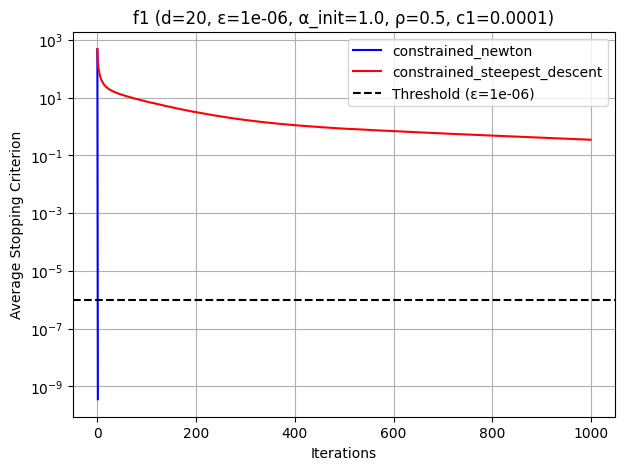

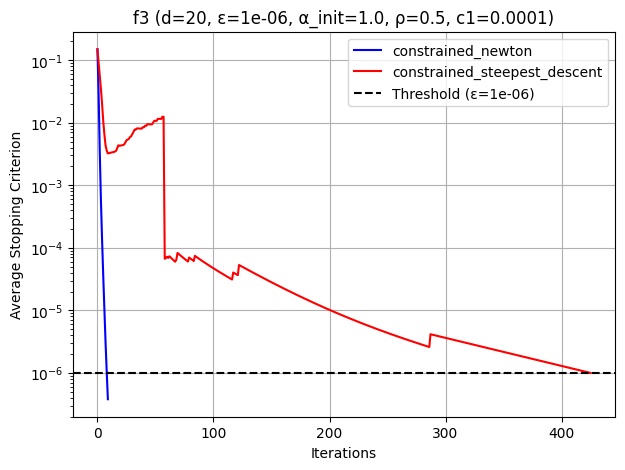

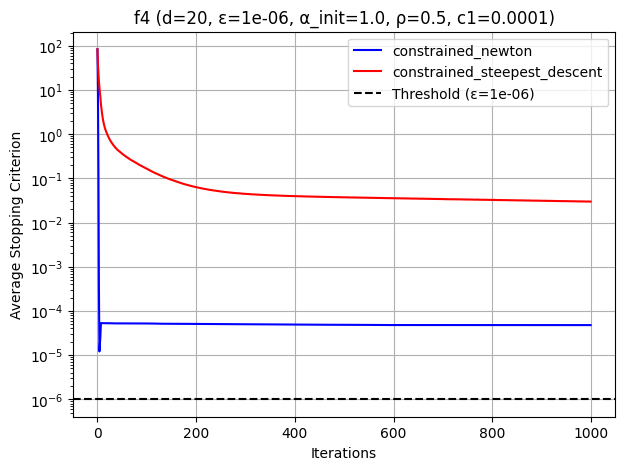

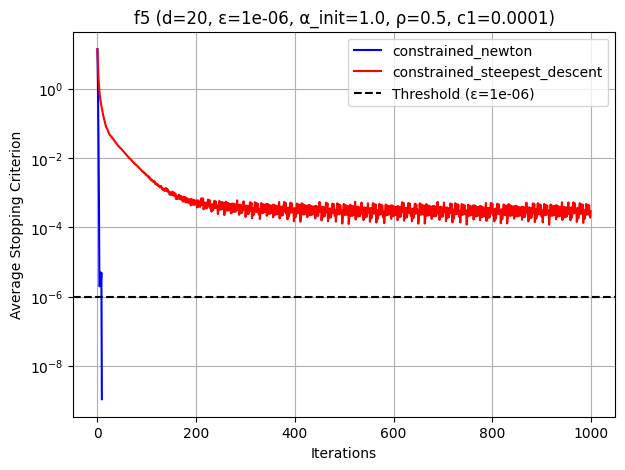

In [171]:
m,n = 19,20 # m should <= n


functions = [(f1, df1, Hf1), (f3, df3, Hf3), (f4, df4, Hf4), (f5, df5, Hf5)]


optimizers = [constrained_newton, constrained_steepest_descent]

test_optimizers_on_function_gradnorm(functions, optimizers, m, n, dimension=n, alpha_init=1.0, rho=0.5, c1=1e-4, epsilon=1e-6, max_iter=1000, num_runs=100)

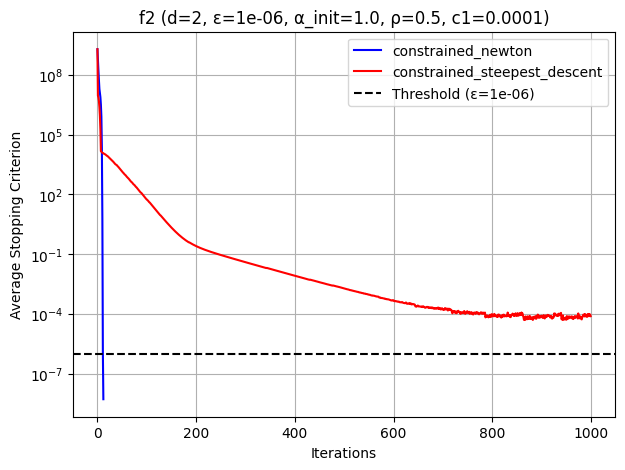

In [162]:
m,n = 1,2 # m should <= n

functions = [ (f2, df2, Hf2)]

optimizers = [constrained_newton, constrained_steepest_descent]

test_optimizers_on_function_gradnorm(functions, optimizers, m, n, dimension=n, alpha_init=1.0, rho=0.5, c1=1e-4, epsilon=1e-6, max_iter=1000, num_runs=100)

In [148]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(248)  # Set seed for reproducibility

def test_optimizers_on_function_dim(functions, optimizers, n_values, alpha_init=1.0, rho=0.5, c1=1e-4, epsilon=1e-9, max_iter=1000, num_runs=5):
    """
    Test optimizers on a given set of functions and plot average and median iterations vs. dimension.
    For each run, uses a different A and b, averages and medians iterations across runs.
    """
    colors = ['b', 'r', 'g', 'orange', 'purple']  # Unique colors for each optimizer

    for f, df, Hf in functions:
        results_mean = {opt.__name__: [] for opt in optimizers}
        results_median = {opt.__name__: [] for opt in optimizers}

        for n in n_values:
            m = n - 1  # Set m = n - 1

            for opt in optimizers:
                iter_counts = []  # Store iterations for each run

                for _ in range(num_runs):
                    # Generate new A and b for each run with full rank
                    U = np.linalg.qr(np.random.randn(m, m))[0]
                    V = np.linalg.qr(np.random.randn(n, n))[0]
                    Sigma = np.diag(np.random.rand(m))
                    A = U @ Sigma @ V[:m, :]
                    b = np.random.uniform(-3, 3, m)

                    # Generate feasible initial point with perturbation
                    x0 = np.linalg.lstsq(A, -b, rcond=None)[0]

                    assert np.allclose(A @ x0 + b, 0, atol=1e-10), "Initial x does not satisfy Ax + b = 0"

                    if opt.__name__ == 'constrained_newton':
                        xs, grad_norms = opt(f, df, Hf, A, b, x0, tol=epsilon, max_iter=max_iter, alpha_init=alpha_init, rho=rho, c1=c1)
                    elif opt.__name__ == 'constrained_steepest_descent':
                        xs, grad_norms = opt(f, df, A, b, x0, tol=epsilon, max_iter=max_iter, c1=c1, rho=rho)  # No Hf
                    else:
                        raise ValueError(f"Unknown optimizer: {opt.__name__}")

                    iter_counts.append(len(grad_norms))  # Store iterations

                results_mean[opt.__name__].append(np.mean(iter_counts))  # Average over runs
                results_median[opt.__name__].append(np.median(iter_counts))  # Median over runs

        # Plot results for this function
        plt.figure(figsize=(8, 5))
        for opt_idx, opt_name in enumerate(results_mean.keys()):
            color = colors[opt_idx % len(colors)]
            plt.plot(n_values, results_mean[opt_name], marker='o', linestyle='-', color=color, label=f"{opt_name} (Mean)")
            plt.plot(n_values, results_median[opt_name], marker='o', linestyle='--', color=color, label=f"{opt_name} (Median)")

        plt.xlabel("Dimension (n)")
        plt.ylabel("Iterations")
        plt.title(f"Convergence Rate vs. Problem Dimension ({f.__name__})")
        plt.grid()
        plt.legend()
        plt.show()

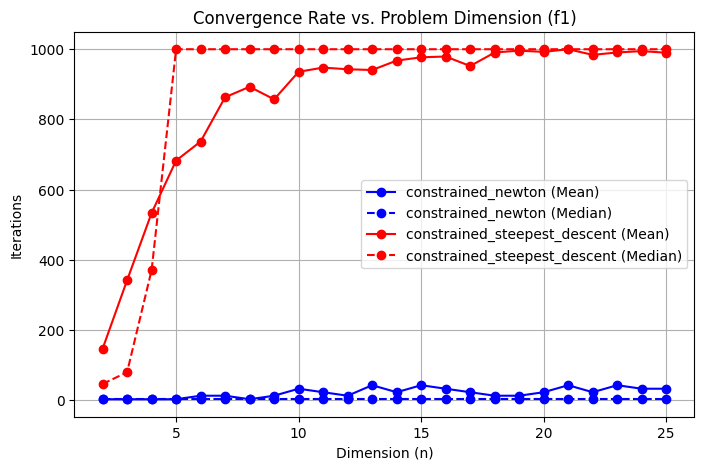

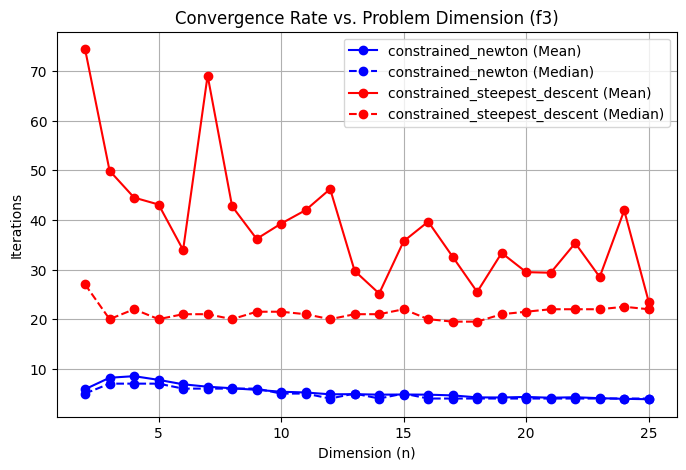

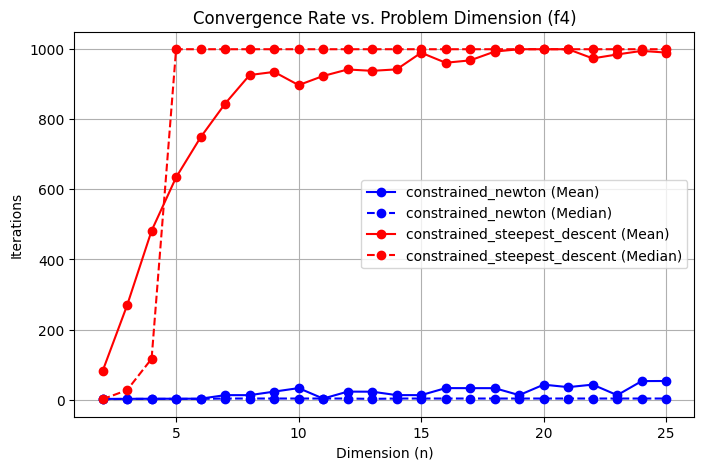

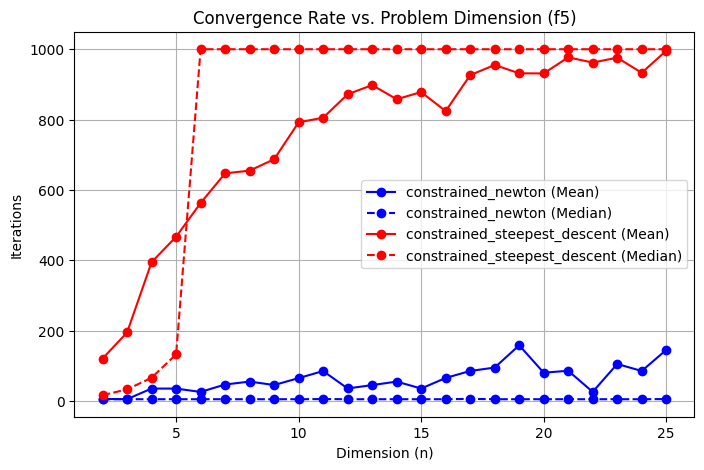

In [152]:

n_values = list(range(2, 26))  # Test for n from 5 to 20
functions = [(f1, df1, Hf1),  (f3, df3, Hf3), (f4, df4, Hf4), (f5, df5, Hf5)]  
optimizers = [constrained_newton, constrained_steepest_descent]

test_optimizers_on_function_dim(functions, optimizers, n_values,  epsilon=1e-6, num_runs=100)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:551: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


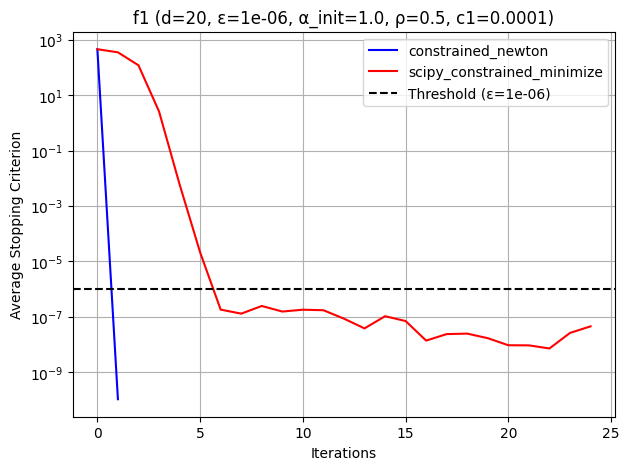

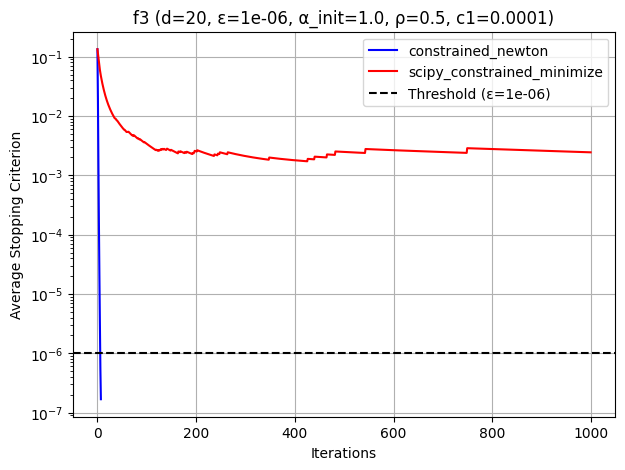

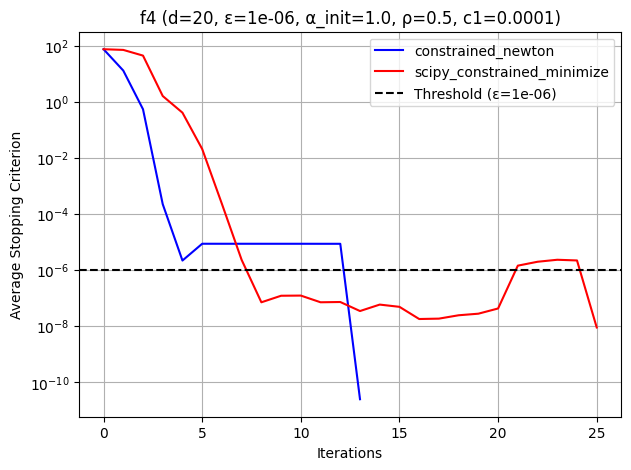

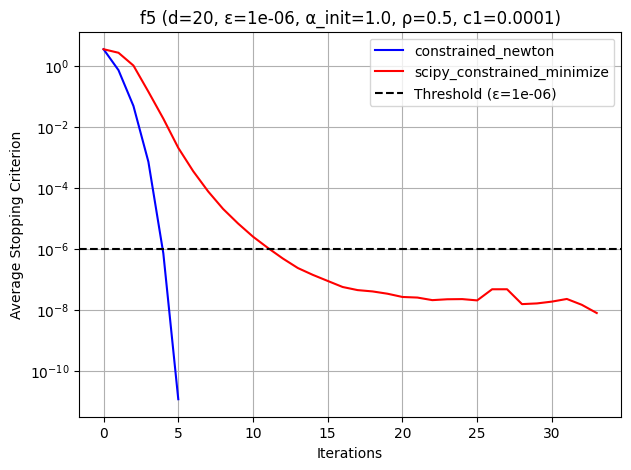

In [58]:
import scipy.optimize as optimize

def scipy_constrained_minimize(f, df, A, b, x0, tol=1e-6, max_iter=1000, alpha_init=1.0, rho=0.5, c1=1e-4):
    """
    Use scipy.optimize.minimize with equality constraints and track gradient norms
    """
    n = len(x0)
    xs = []
    grad_norms = []
    
    # Define the projection matrix for gradient calculation
    P = np.eye(n) - A.T @ np.linalg.inv(A @ A.T) @ A
    
    def logging_f(x):
        xs.append(x.copy())
        # Calculate projected gradient norm
        projected_gradient = P @ df(x)
        norm = np.linalg.norm(projected_gradient)
        grad_norms.append(norm)
        return f(x)
    
    # Define the constraint
    constraints = [{'type': 'eq', 'fun': lambda x: A @ x + b, 'jac': lambda x: A}]
    
    # Define the optimization problem
    result = optimize.minimize(
        logging_f, x0, jac=df, constraints=constraints,
        method='trust-constr', options={'maxiter': max_iter, 'barrier_tol': tol}
    )
    
    return result.x, np.array(grad_norms)


m,n = 19,20 # m should <= n


functions = [(f1, df1, Hf1), (f3, df3, Hf3), (f4, df4, Hf4), (f5, df5, Hf5)]


optimizers = [constrained_newton, scipy_constrained_minimize]

test_optimizers_on_function_gradnorm(functions, optimizers, m, n, dimension=n, alpha_init=1.0, rho=0.5, c1=1e-4, epsilon=1e-6, max_iter=1000, num_runs=50)

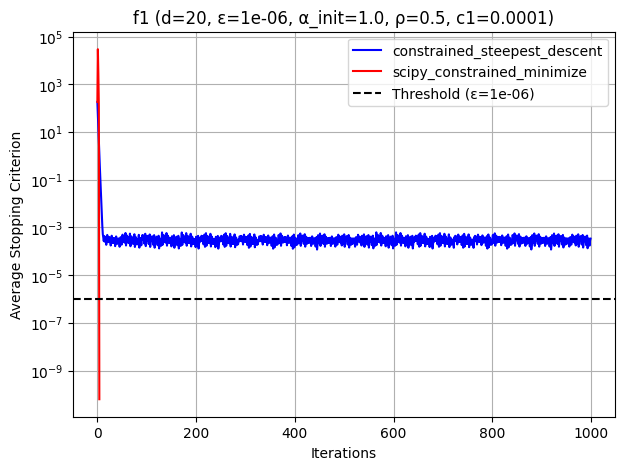

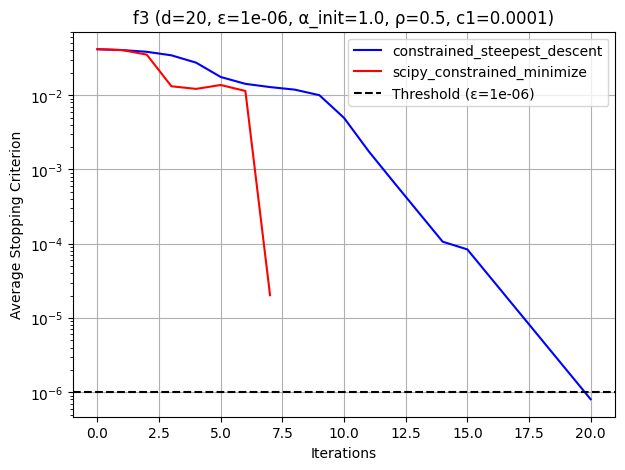

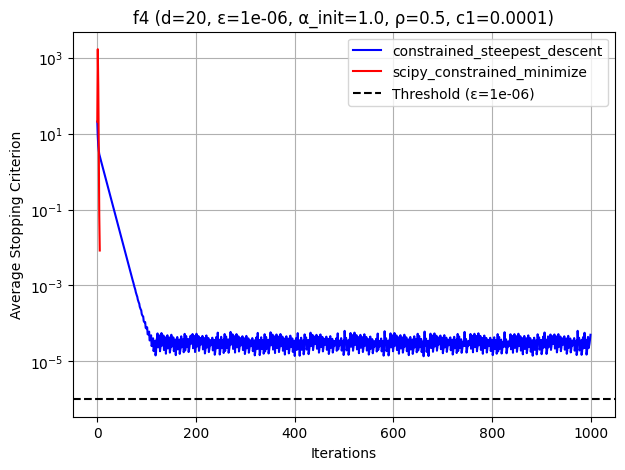

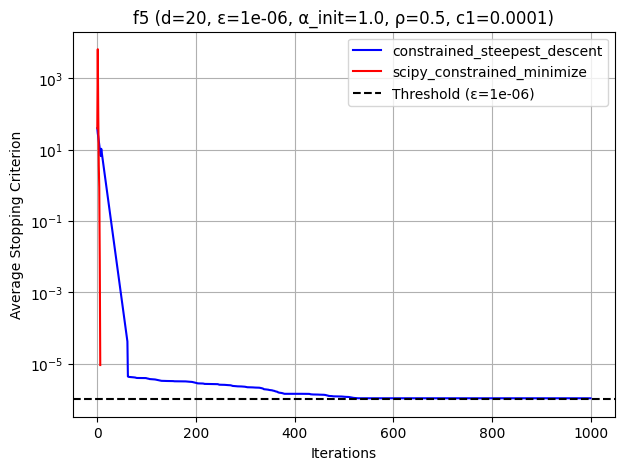

In [59]:
def scipy_constrained_minimize(f, df, A, b, x0, tol=1e-6, max_iter=1000, alpha_init=1.0, rho=0.5, c1=1e-4):
    """
    Use scipy.optimize.minimize with equality constraints and track gradient norms
    """
    n = len(x0)
    xs = []
    grad_norms = []
    
    # Define the projection matrix for gradient calculation
    P = np.eye(n) - A.T @ np.linalg.inv(A @ A.T) @ A
    
    def logging_f(x):
        xs.append(x.copy())
        # Calculate projected gradient norm
        projected_gradient = P @ df(x)
        norm = np.linalg.norm(projected_gradient)
        grad_norms.append(norm)
        return f(x)
    
    # Define the constraint
    constraints = [{'type': 'eq', 'fun': lambda x: A @ x + b, 'jac': lambda x: A}]
    
    # Define the optimization problem
    result = optimize.minimize(
        logging_f, x0, jac=df, constraints=constraints,
        method='SLSQP', options={'maxiter': max_iter, 'ftol': tol}
    )
    
    return result.x, np.array(grad_norms)


m,n = 19,20 # m should <= n


functions = [(f1, df1, Hf1), (f3, df3, Hf3), (f4, df4, Hf4), (f5, df5, Hf5)]


optimizers = [constrained_steepest_descent, scipy_constrained_minimize]

test_optimizers_on_function_gradnorm(functions, optimizers, m, n, dimension=n, alpha_init=1.0, rho=0.5, c1=1e-4, epsilon=1e-6, max_iter=1000, num_runs=2)

In [63]:
import numpy as np

def test_known_solution_1():
    """
    Test Case 1: Simple quadratic with linear constraint
    f(x) = (x1 - 2)^2 + (x2 - 3)^2 with constraint x1 + x2 = 1
    The analytical solution is x = [0, 1]
    """
    def f(x): return (x[0] - 2)**2 + (x[1] - 3)**2
    def df(x): return np.array([2*(x[0] - 2), 2*(x[1] - 3)])
    def Hf(x): return np.diag([2, 2])
    
    A = np.array([[1, 1]])  # x1 + x2 = 1
    b = np.array([-1])
    x0 = np.array([0.5, 0.5])  # Feasible initial point
    
    # Test Newton
    xs_newton, _ = constrained_newton(f, df, Hf, A, b, x0)
    x_newton = xs_newton[-1]
    
    # Test Steepest Descent
    xs_sd, _ = constrained_steepest_descent(f, df, A, b, x0)
    x_sd = xs_sd[-1]
    
    # Check results
    print("Test Case 1: Simple Quadratic")
    print("Known solution: [0, 1]")
    print("Newton solution:", x_newton)
    print("Steepest descent solution:", x_sd)
    
    # Verify constraints are satisfied
    print("Newton constraint violation:", np.linalg.norm(A @ x_newton + b))
    print("SD constraint violation:", np.linalg.norm(A @ x_sd + b))
    print("------------------------------")

def test_known_solution_2():
    """
    Test Case 2: Constrained Rosenbrock
    f(x) = 100*(x2 - x1^2)^2 + (1 - x1)^2 with constraint x1 + x2 = 1
    The analytical solution is x = [0.5, 0.5]
    """
    def f(x): return 100*(x[1] - x[0]**2)**2 + (1 - x[0])**2
    def df(x): return np.array([-400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0]), 
                              200*(x[1] - x[0]**2)])
    def Hf(x): return np.array([
        [1200*x[0]**2 - 400*x[1] + 2, -400*x[0]],
        [-400*x[0], 200]
    ])
    
    A = np.array([[1, 1]])  # x1 + x2 = 1
    b = np.array([-1])
    x0 = np.array([0.5, 0.5])  # Feasible initial point
    
    # Test Newton
    xs_newton, _ = constrained_newton(f, df, Hf, A, b, x0)
    x_newton = xs_newton[-1]
    
    # Test Steepest Descent
    xs_sd, _ = constrained_steepest_descent(f, df, A, b, x0)
    x_sd = xs_sd[-1]
    
    # Check results
    print("Test Case 2: Constrained Rosenbrock")
    print("Known solution: [0.5, 0.5]")
    print("Newton solution:", x_newton)
    print("Steepest descent solution:", x_sd)
    
    # Verify constraints are satisfied
    print("Newton constraint violation:", np.linalg.norm(A @ x_newton + b))
    print("SD constraint violation:", np.linalg.norm(A @ x_sd + b))
    print("------------------------------")

def test_known_solution_3():
    """
    Test Case 3: 3D quadratic with two constraints
    f(x) = x1^2 + x2^2 + x3^2 with constraints x1 + x2 + x3 = 1 and x1 + 2*x2 + 3*x3 = 2
    The analytical solution is x = [0, 0, 1]
    """
    def f(x): return x[0]**2 + x[1]**2 + x[2]**2
    def df(x): return 2*x
    def Hf(x): return 2*np.eye(3)
    
    A = np.array([[1, 1, 1], [1, 2, 3]])  # Two constraints
    b = np.array([-1, -2])
    x0 = np.array([1/3, 1/3, 1/3])  # Feasible initial point
    
    # Test Newton
    xs_newton, _ = constrained_newton(f, df, Hf, A, b, x0)
    x_newton = xs_newton[-1]
    
    # Test Steepest Descent
    xs_sd, _ = constrained_steepest_descent(f, df, A, b, x0)
    x_sd = xs_sd[-1]
    
    # Check results
    print("Test Case 3: 3D Quadratic with Two Constraints")
    print("Known solution: [0, 0, 1]")
    print("Newton solution:", x_newton)
    print("Steepest descent solution:", x_sd)
    
    # Verify constraints are satisfied
    print("Newton constraint violation:", np.linalg.norm(A @ x_newton + b))
    print("SD constraint violation:", np.linalg.norm(A @ x_sd + b))
    print("------------------------------")

def test_known_solution_4():
    """
    Test Case 4: Distance to a point with a plane constraint
    f(x) = (x1 - 3)^2 + (x2 - 4)^2 + (x3 - 5)^2 with constraint x1 + x2 + x3 = 0
    The analytical solution is x = [1, 1, -2]
    """
    def f(x): return (x[0] - 3)**2 + (x[1] - 4)**2 + (x[2] - 5)**2
    def df(x): return 2*np.array([x[0] - 3, x[1] - 4, x[2] - 5])
    def Hf(x): return 2*np.eye(3)
    
    A = np.array([[1, 1, 1]])  # Plane constraint
    b = np.array([0])
    x0 = np.array([0, 0, 0])  # Feasible initial point
    
    # Test Newton
    xs_newton, _ = constrained_newton(f, df, Hf, A, b, x0)
    x_newton = xs_newton[-1]
    
    # Test Steepest Descent
    xs_sd, _ = constrained_steepest_descent(f, df, A, b, x0)
    x_sd = xs_sd[-1]
    
    # Check results
    print("Test Case 4: Distance to a Point with Plane Constraint")
    print("Known solution: [1, 1, -2]")  # This is the projection of [3,4,5] onto the plane x1+x2+x3=0
    print("Newton solution:", x_newton)
    print("Steepest descent solution:", x_sd)
    
    # Verify constraints are satisfied
    print("Newton constraint violation:", np.linalg.norm(A @ x_newton + b))
    print("SD constraint violation:", np.linalg.norm(A @ x_sd + b))
    print("------------------------------")

# Run all test cases
test_known_solution_1()
test_known_solution_2()
test_known_solution_3()
test_known_solution_4()

Test Case 1: Simple Quadratic
Known solution: [0, 1]
Newton solution: [0. 1.]
Steepest descent solution: [0. 1.]
Newton constraint violation: 0.0
SD constraint violation: 0.0
------------------------------
Test Case 2: Constrained Rosenbrock
Known solution: [0.5, 0.5]
Newton solution: [0.61879562 0.38120438]
Steepest descent solution: [0.61879562 0.38120438]
Newton constraint violation: 0.0
SD constraint violation: 1.3322676295501878e-15
------------------------------
Test Case 3: 3D Quadratic with Two Constraints
Known solution: [0, 0, 1]
Newton solution: [0.33333333 0.33333333 0.33333333]
Steepest descent solution: [0.33333333 0.33333333 0.33333333]
Newton constraint violation: 0.0
SD constraint violation: 0.0
------------------------------
Test Case 4: Distance to a Point with Plane Constraint
Known solution: [1, 1, -2]
Newton solution: [-1.  0.  1.]
Steepest descent solution: [-1.00000000e+00  3.88578059e-16  1.00000000e+00]
Newton constraint violation: 0.0
SD constraint violation: